# sub2データのアノテーター間比較

In [1]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import json

In [2]:
with open('../data/sub2_recipe_10.json', 'r', encoding='utf-8') as f:
    recipe = json.load(f)

recipe

[{'title': '例題1：トマトの冷やしおでん風',
  'ingredients': ['トマト 4コ（300g）',
   '油揚げ 40g',
   '【A】 だし カップ1+1/2',
   '【A】 うす口しょうゆ 大さじ1',
   'すだち（薄い輪切り） 適量',
   '七味とうがらし 適宜'],
  'instructions': ['1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。',
   '2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。',
   '3. 2の小鍋に1の油揚げを加え、しんなりとするまで1分間ほど煮る。煮汁ごと2の保存容器に注ぎ入れ、そのまま冷ます。',
   '4. 器に盛ってすだちを添え、あれば七味とうがらしをふる。']},
 {'title': '例題2：ジャンボプリン',
  'ingredients': ['【カラメルソース】 グラニュー糖 80g',
   '【カラメルソース】 水 小さじ1',
   '卵 3コ',
   '卵黄 3コ分',
   'グラニュー糖 120g',
   '牛乳 カップ4',
   '生クリーム カップ1/2'],
  'instructions': ['1. 【カラメルソース】をつくる。小鍋にグラニュー糖を入れて分量の水を鍋の縁から加え、混ぜずに弱火にかける。グラニュー糖が溶けはじめたら、鍋を揺すって焦げつかないようにし、液状になって色づくまで5～10分間加熱する。泡が落ち着いて焦げ茶色になる一歩手前で火から下ろす。型に注ぎ入れ、底面全体に広げる。',
   '2. ボウルに卵と卵黄を入れてよく溶きほぐし、グラニュー糖を加えて泡立てないようによく混ぜる。',
   '3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま20秒間火にかけ、ふきこぼれる直前で火を止める。',
   '4. 2に3の1/4量を加え、泡立て器でよく混ぜる。残りの3を一気に加え、ゴムべらに持ちかえてしっかり混ぜ合わせる。',
   '5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに入れたら、天板の高さギリギリまで熱湯を静かに注ぎ入

In [3]:
PATH = "../outputs/"
ANNOTATORS = ["A", "B", "C", "ad2"]

raw_data = {}
for ann in ANNOTATORS:
    with open(PATH + f"{ann}_sub2_annotated.json", encoding="utf-8") as f:
        raw_data[ann] = json.load(f)

n_recipes = len(raw_data["A"])
titles = [r["title"] for r in raw_data["A"]]
for ann in ANNOTATORS:
    assert len(raw_data[ann]) == n_recipes
    assert [r["title"] for r in raw_data[ann]] == titles

titles

['例題1：トマトの冷やしおでん風',
 '例題2：ジャンボプリン',
 '本格チキンビリヤニ',
 'フランス風豚バラ大根',
 '白菜と手羽先のピリ辛煮',
 'アスパラの豚肉巻き',
 'ナポリタン',
 '簡単ティラミス',
 'ワザあり豚カツ',
 '春の豚たまあえ',
 '牛肉の赤ワイン煮込み',
 '春キャベツと春にんじんのスープ']

In [4]:
def summarize_recipe(recipe_idx, title, recipe, annotator):
    """steps ごとに state 数・最終位置・使用容器・使用道具を集計"""
    rows = []
    for step in recipe["world_state_list"]:
        containers, vessels, tools = set(), set(), set()
        for state in step["state_list"]:
            if state["final_position"]:
                containers.add(state["final_position"])
            for inter in state["utensil_interactions_list"]:
                vessels.update(inter["vessel"])
                tools.update(inter["tools"])
        rows.append({
            "recipe_idx": recipe_idx,
            "title": title,
            "step_after": step["step_after"],
            "annotator": annotator,
            "n_states": len(step["state_list"]),
            "containers": containers,
            "vessels": vessels,
            "tools": tools,
        })
    return rows

rows = []
for ann in ANNOTATORS:
    for i, ann_recipe in enumerate(raw_data[ann]):
        rows += summarize_recipe(i, ann_recipe["title"], ann_recipe, ann)

long_df = pd.DataFrame(rows)
long_df.head()

,recipe_idx,title,step_after,annotator,n_states,containers,vessels,tools
0,0,例題1：トマトの冷やしおでん風,0,A,6,{},{},{}
1,0,例題1：トマトの冷やしおでん風,1,A,2,{まな板},{まな板},{包丁}
2,0,例題1：トマトの冷やしおでん風,2,A,2,{鍋（蓋付き）},"{ボウル, 鍋（蓋付き）}",{菜箸}
3,0,例題1：トマトの冷やしおでん風,3,A,1,{ボウル},"{まな板, ボウル, 鍋（蓋付き）}",{菜箸}
4,0,例題1：トマトの冷やしおでん風,4,A,1,{盛り付け皿・器},"{盛り付け皿・器, ボウル}",{}


In [5]:
def jaccard(a, b):
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

by_step = long_df.set_index(["recipe_idx", "step_after", "annotator"])
step_keys = long_df[["recipe_idx", "title", "step_after"]].drop_duplicates()

# 一致度は ad2（正解役）を基準にした A-ad2 / B-ad2 / C-ad2 のみを対象とする
OTHER_ANNOTATORS = [a for a in ANNOTATORS if a != "ad2"]

pair_rows = []
for _, key in step_keys.iterrows():
    ri, title, step = key["recipe_idx"], key["title"], key["step_after"]
    per_ann = {ann: by_step.loc[(ri, step, ann)] for ann in ANNOTATORS}
    for other in OTHER_ANNOTATORS:
        a1, a2 = "ad2", other
        pair_rows.append({
            "recipe_idx": ri,
            "title": title,
            "step_after": step,
            "pair": f"{a1}-{a2}",
            "n_states_match": per_ann[a1]["n_states"] == per_ann[a2]["n_states"],
            "container_jaccard": jaccard(per_ann[a1]["containers"], per_ann[a2]["containers"]),
            "vessel_jaccard": jaccard(per_ann[a1]["vessels"], per_ann[a2]["vessels"]),
            "tool_jaccard": jaccard(per_ann[a1]["tools"], per_ann[a2]["tools"]),
        })

pair_df = pd.DataFrame(pair_rows)
pair_df.head()

,recipe_idx,title,step_after,pair,n_states_match,container_jaccard,vessel_jaccard,tool_jaccard
0,0,例題1：トマトの冷やしおでん風,0,ad2-A,True,1.0,1.0,1.0
1,0,例題1：トマトの冷やしおでん風,0,ad2-B,True,1.0,1.0,1.0
2,0,例題1：トマトの冷やしおでん風,0,ad2-C,True,1.0,1.0,1.0
3,0,例題1：トマトの冷やしおでん風,1,ad2-A,True,1.0,1.0,1.0
4,0,例題1：トマトの冷やしおでん風,1,ad2-B,True,0.5,0.5,1.0


## step の状態数が一致しないケース

In [6]:
n_states_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                               columns="annotator", values="n_states")[ANNOTATORS].reset_index()
n_states_wide["all_match"] = n_states_wide[ANNOTATORS].nunique(axis=1) == 1

mismatches = n_states_wide[~n_states_wide["all_match"]].drop(columns="all_match")
mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad2
2,0,例題1：トマトの冷やしおでん風,2,2,2,1,1
25,4,白菜と手羽先のピリ辛煮,2,1,2,2,2
38,7,簡単ティラミス,2,1,2,1,2


In [7]:
# recipe データから手順文を結合
# step_after=0 は初期状態（材料のみ）、step_after=N (N>=1) は instructions[N-1] に対応
instruction_map = {}
for i, r in enumerate(recipe):
    instruction_map[(i, 0)] = "(初期状態)"
    for j, text in enumerate(r["instructions"], start=1):
        instruction_map[(i, j)] = text

long_df["instruction"] = long_df.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
mismatches["instruction"] = mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad2,instruction
2,0,例題1：トマトの冷やしおでん風,2,2,2,1,1,2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、...
25,4,白菜と手羽先のピリ辛煮,2,1,2,2,2,2. フライパンに油大さじ2を中火で熱し、白菜の根元の部分を入れて強火で焼く。焼き色がついた...
38,7,簡単ティラミス,2,1,2,1,2,2. インスタントコーヒーは分量の湯で溶く。ビスケット8枚を1枚ずつ【コーヒー】にサッと浸し...


## 各アノテーターが実際に書いた state の中身

In [8]:
def get_states_df(recipe_idx, step_after):
    """指定した recipe / step について、各アノテーターが書いた state_list をそのまま並べる"""
    rows = []
    for ann in ANNOTATORS:
        step = raw_data[ann][recipe_idx]["world_state_list"][step_after]
        assert step["step_after"] == step_after
        for state in step["state_list"]:
            vessels, tools = set(), set()
            for inter in state["utensil_interactions_list"]:
                vessels.update(inter["vessel"])
                tools.update(inter["tools"])
            rows.append({
                "annotator": ann,
                "id": state["id"],
                "name": state["name"],
                "final_position": state["final_position"],
                "vessel": ", ".join(sorted(vessels)),
                "tools": ", ".join(sorted(tools)),
            })
    return pd.DataFrame(rows)

def show_step(recipe_idx, step_after):
    title = titles[recipe_idx]
    instruction = instruction_map[(recipe_idx, step_after)]
    print(f"[{title}] step_after={step_after}")
    print(instruction)
    display(get_states_df(recipe_idx, step_after))

show_step(0, 1)

[例題1：トマトの冷やしおでん風] step_after=1
1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。


,annotator,id,name,final_position,vessel,tools
0,A,e7776b14,切ったトマト,まな板,まな板,包丁
1,A,91780864,切った油揚げ,まな板,まな板,包丁
2,B,39ae4c8b,ヘタをくり抜いたトマト,ボウル,ボウル,包丁
3,B,2b19c86e,切った油揚げ,まな板,まな板,包丁
4,C,8176f8fc,ヘタをくりぬいたトマト,まな板,まな板,包丁
5,C,5fefbf50,短冊形にした油揚げ,まな板,まな板,包丁
6,ad2,e10655e5,ヘタをくり抜いたトマト,まな板,まな板,包丁
7,ad2,dc434abf,切った油揚げ,まな板,まな板,包丁


### 不一致だった step をすべて表示

In [9]:
for _, row in mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,final_position,vessel,tools
0,A,8c8aea99,加熱した味付けトマト,鍋（蓋付き）,"ボウル, 鍋（蓋付き）",菜箸
1,A,850393b5,加熱した調味料,鍋（蓋付き）,鍋（蓋付き）,菜箸
2,B,d86825f0,煮汁,鍋（蓋付き）,鍋（蓋付き）,菜箸
3,B,21a7d338,皮を剥いたトマト,鍋（蓋付き）,"ボウル, 鍋（蓋付き）",菜箸
4,C,7a8e4648,皮をむいたトマト,鍋（蓋付き）,"まな板, ボウル, 鍋（蓋付き）","網目の粗い網杓子, 道具不使用"
5,ad2,4ef62c39,皮をむいたトマト,鍋（蓋付き）,"まな板, ボウル, 鍋（蓋付き）","網目の粗い網杓子, 道具不使用"



[白菜と手羽先のピリ辛煮] step_after=2
2. フライパンに油大さじ2を中火で熱し、白菜の根元の部分を入れて強火で焼く。焼き色がついたら返し、両面がこんがり焼けたら、火を止めて取り出す。手羽先は皮の厚いほうを下にして並べ入れ（先端も入れる）、中火で焼く。焼き色がついたら返して同様に焼く。


,annotator,id,name,final_position,vessel,tools
0,A,66a10692,加熱した白菜と手羽先,フライパン（蓋付き）,フライパン（蓋付き）,菜箸
1,B,82e0e289,焼いた白菜の根元,ボウル,"まな板, フライパン（蓋付き）, ボウル",菜箸
2,B,ee35efa0,焼いた手羽先,フライパン（蓋付き）,"フライパン（蓋付き）, 生肉・生魚用まな板",菜箸
3,C,2f8ac0bb,焼いた白菜の根元,ボウル,"まな板, フライパン（蓋付き）, ボウル",菜箸
4,C,c1b4d6c7,手羽先を焼いたもの,フライパン（蓋付き）-2,"まな板, フライパン（蓋付き）-2",菜箸
5,ad2,56142eda,焼いた白菜の根本部分,ボウル-2,"まな板, フライパン（蓋付き）, ボウル-2",菜箸
6,ad2,c9f257ff,焼いた手羽先,フライパン（蓋付き）,"フライパン（蓋付き）, ボウル",菜箸



[簡単ティラミス] step_after=2
2. インスタントコーヒーは分量の湯で溶く。ビスケット8枚を1枚ずつ【コーヒー】にサッと浸し、器に2枚重ねにして並べ入れる。


,annotator,id,name,final_position,vessel,tools
0,A,9d0c94c6,インスタントコーヒーとビスケット,盛り付け皿・器,盛り付け皿・器,スプーン
1,B,94612dfd,【コーヒー】,ボウル-2,ボウル-2,菜箸
2,B,a3b41403,コーヒーに浸したビスケット,盛り付け皿・器,"ボウル-2, 盛り付け皿・器",菜箸
3,C,7dcdae19,【コーヒー】に浸したビスケット,盛り付け皿・器,"ボウル-2, 盛り付け皿・器","スプーン, トング"
4,ad2,95f1f6b1,ビスケット8枚をコーヒーに浸し器に並び入れたもの,盛り付け皿・器,"None_マグカップ, 盛り付け皿・器",道具不使用
5,ad2,d5eb7685,コーヒー,None_マグカップ,None_マグカップ,スプーン


## 最終位置（final_position）が一致しないケース

In [10]:
containers_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                                 columns="annotator", values="containers")[ANNOTATORS].reset_index()
containers_wide["all_match"] = containers_wide[ANNOTATORS].apply(
    lambda row: len({frozenset(s) for s in row}) == 1, axis=1
)

container_mismatches = containers_wide[~containers_wide["all_match"]].drop(columns="all_match")
container_mismatches["instruction"] = container_mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
container_mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad2,instruction
1,0,例題1：トマトの冷やしおでん風,1,{まな板},"{まな板, ボウル}",{まな板},{まな板},1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。
8,1,例題2：ジャンボプリン,3,{鍋（蓋付き）-2},{鍋（蓋付き）},{鍋（蓋付き）-2},{鍋（蓋付き）-2},3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま2...
9,1,例題2：ジャンボプリン,4,{鍋（蓋付き）-2},{ボウル},{ボウル},{ボウル},4. 2に3の1/4量を加え、泡立て器でよく混ぜる。残りの3を一気に加え、ゴムべらに持ちかえ...
10,1,例題2：ジャンボプリン,5,{盛り付け皿・器},{流し型},{流し型},{流し型},5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに...
15,2,本格チキンビリヤニ,3,{フライパン（蓋付き）-2},{フライパン（蓋付き）},{フライパン（蓋付き）},{フライパン（蓋付き）},3. フライパンに1の鶏肉、塩水、カレー粉大さじ1を加えて、煮汁がトロリとなるまで煮る。
24,4,白菜と手羽先のピリ辛煮,1,"{まな板, 生肉・生魚用まな板}","{まな板, 生肉・生魚用まな板}",{まな板},"{まな板, ボウル}",1. 白菜は芯をつけたまま長さを3等分に切り、根元の部分は縦4等分に切る。にんにくは縦半分に...
25,4,白菜と手羽先のピリ辛煮,2,{フライパン（蓋付き）},"{フライパン（蓋付き）, ボウル}","{ボウル, フライパン（蓋付き）-2}","{フライパン（蓋付き）, ボウル-2}",2. フライパンに油大さじ2を中火で熱し、白菜の根元の部分を入れて強火で焼く。焼き色がついた...
29,5,アスパラの豚肉巻き,2,{まな板},{バット},{バット},{バット},2. アスパラガス1本に豚肉2枚を1枚ずつ巻く。穂先の部分は残して斜めに巻きつける。巻き終わ...
30,5,アスパラの豚肉巻き,3,{フライパン（蓋付き）},{盛り付け皿・器},{盛り付け皿・器},{盛り付け皿・器},3. フライパンに油小さじ1を中火で熱し、2を巻き終わりを下にして並べ入れる。時々転がしなが...
33,6,ナポリタン,2,{まな板},"{まな板, 生肉・生魚用まな板}",{まな板},{まな板},2. ハムは半分に切って1cm幅に切る。たまねぎは縦に薄切りにし、ピーマンは縦半分に切ってヘ...


### 不一致だった step をすべて表示

In [11]:
for _, row in container_mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=1
1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。


,annotator,id,name,final_position,vessel,tools
0,A,e7776b14,切ったトマト,まな板,まな板,包丁
1,A,91780864,切った油揚げ,まな板,まな板,包丁
2,B,39ae4c8b,ヘタをくり抜いたトマト,ボウル,ボウル,包丁
3,B,2b19c86e,切った油揚げ,まな板,まな板,包丁
4,C,8176f8fc,ヘタをくりぬいたトマト,まな板,まな板,包丁
5,C,5fefbf50,短冊形にした油揚げ,まな板,まな板,包丁
6,ad2,e10655e5,ヘタをくり抜いたトマト,まな板,まな板,包丁
7,ad2,dc434abf,切った油揚げ,まな板,まな板,包丁



[例題2：ジャンボプリン] step_after=3
3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま20秒間火にかけ、ふきこぼれる直前で火を止める。


,annotator,id,name,final_position,vessel,tools
0,A,bec7828e,加熱した牛乳と生クリーム,鍋（蓋付き）-2,鍋（蓋付き）-2,耐熱ゴムべら
1,B,6f73550d,温めた牛乳と生クリームを混ぜたもの,鍋（蓋付き）,鍋（蓋付き）,耐熱ゴムべら
2,C,ffe61e63,牛乳と生クリームを沸騰させたもの,鍋（蓋付き）-2,鍋（蓋付き）-2,耐熱ゴムべら
3,ad2,edcf883d,牛乳・生クリームを沸騰させたもの,鍋（蓋付き）-2,鍋（蓋付き）-2,耐熱ゴムべら



[例題2：ジャンボプリン] step_after=4
4. 2に3の1/4量を加え、泡立て器でよく混ぜる。残りの3を一気に加え、ゴムべらに持ちかえてしっかり混ぜ合わせる。


...

,annotator,id,name,final_position,vessel,tools
0,A,1ce00ce3,加熱した豚肉,ざる,"ざる, 鍋（蓋付き）",菜箸
1,B,d4627ff2,茹でた豚肉,ざる,"ざる, 鍋（蓋付き）",菜箸
2,C,70734c54,茹でた豚肉,None_ざる2,"None_ざる2, 鍋（蓋付き）",トング
3,ad2,44cd5785,茹でて粗熱を取った豚肉,None_ざる-2,"None_ざる-2, 鍋（蓋付き）",菜箸



[春キャベツと春にんじんのスープ] step_after=1
1. キャベツは太い軸を薄くそぎ（全体備考参照）、3cm四方に切る。にんじんは1cm角に、ベーコンは1cm幅に切る。


,annotator,id,name,final_position,vessel,tools
0,A,b9bd9c18,切ったキャベツ,まな板,まな板,包丁
1,A,058a36e6,切ったにんじん,まな板,まな板,包丁
2,A,ea7ce73d,切ったベーコン,まな板,まな板,包丁
3,B,10acf9cd,切ったキャベツ,まな板,まな板,包丁
4,B,c31e1b96,切ったにんじん,まな板,まな板,包丁
5,B,d00ed3e3,切ったベーコン,生肉・生魚用まな板,生肉・生魚用まな板,包丁
6,C,84c2cd20,切ったキャベツ,まな板,まな板,包丁
7,C,f0ee41cc,切った人参,まな板,まな板,包丁
8,C,0ffa307c,切ったベーコン,まな板,まな板,包丁
9,ad2,1d8f3498,切ったキャベツ,まな板,まな板,包丁



[春キャベツと春にんじんのスープ] step_after=3
3. 水カップ2、スープのもと、ローリエを加えて中火にし、煮立ったら弱めの中火にしてふたをし、約5分間煮る。ふたを外して混ぜ、再びふたをしてさらに1～2分間煮る。塩・こしょう各少々で味を調える。


,annotator,id,name,final_position,vessel,tools
0,A,f6ea280d,春キャベツと春にんじんのスープ,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）",
1,B,5f3916c5,春キャベツと春にんじんのスープ,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）","おたま, 木製へら"
2,C,b19f5224,春キャベツと春にんじんのスープ,鍋（蓋付き）,"盛り付け皿・器, 鍋（蓋付き）",おたま
3,ad2,57ee1e26,春キャベツと春にんじんのスープ,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）",おたま


## 使用容器（vessel）が一致しないケース

In [12]:
vessels_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                              columns="annotator", values="vessels")[ANNOTATORS].reset_index()
vessels_wide["all_match"] = vessels_wide[ANNOTATORS].apply(
    lambda row: len({frozenset(s) for s in row}) == 1, axis=1
)

vessel_mismatches = vessels_wide[~vessels_wide["all_match"]].drop(columns="all_match")
vessel_mismatches["instruction"] = vessel_mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
vessel_mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad2,instruction
1,0,例題1：トマトの冷やしおでん風,1,{まな板},"{まな板, ボウル}",{まな板},{まな板},1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。
2,0,例題1：トマトの冷やしおでん風,2,"{ボウル, 鍋（蓋付き）}","{ボウル, 鍋（蓋付き）}","{まな板, ボウル, 鍋（蓋付き）}","{まな板, ボウル, 鍋（蓋付き）}",2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、...
8,1,例題2：ジャンボプリン,3,{鍋（蓋付き）-2},{鍋（蓋付き）},{鍋（蓋付き）-2},{鍋（蓋付き）-2},3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま2...
9,1,例題2：ジャンボプリン,4,"{鍋（蓋付き）-2, ボウル}","{ボウル, 鍋（蓋付き）}","{鍋（蓋付き）-2, ボウル}","{鍋（蓋付き）-2, ボウル}",4. 2に3の1/4量を加え、泡立て器でよく混ぜる。残りの3を一気に加え、ゴムべらに持ちかえ...
10,1,例題2：ジャンボプリン,5,"{鍋（蓋付き）-2, 流し型, 盛り付け皿・器}","{流し型, ボウル}","{流し型, ボウル}","{流し型, ボウル}",5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに...
11,1,例題2：ジャンボプリン,6,{盛り付け皿・器},"{流し型, 盛り付け皿・器}","{流し型, 盛り付け皿・器}","{流し型, 盛り付け皿・器}",6. オーブンから出して粗熱を取り、冷蔵庫でよく冷やす。型とプリンの間に一周グルリとナイフを...
15,2,本格チキンビリヤニ,3,{フライパン（蓋付き）-2},"{フライパン（蓋付き）, ボウル, ボウル-2}","{フライパン（蓋付き）, ボウル, フライパン（蓋付き）-2, ボウル-2}","{フライパン（蓋付き）, ボウル, ボウル-2}",3. フライパンに1の鶏肉、塩水、カレー粉大さじ1を加えて、煮汁がトロリとなるまで煮る。
16,2,本格チキンビリヤニ,4,"{ざる, 盛り付け皿・器, フライパン（蓋付き）-2, フライパン（蓋付き）, 鍋（蓋付き）...","{ざる, 盛り付け皿・器, フライパン（蓋付き）, 鍋（蓋付き）, ボウル-3}","{鍋（蓋付き）-2, 盛り付け皿・器}","{ざる, 鍋（蓋付き）-2, 盛り付け皿・器, フライパン（蓋付き）, ボウル-3}",4. 厚手の鍋の底にバター適量を塗る。米、カレーベースの順に交互に3層ほど重ねて入れる。あれ...
19,3,フランス風豚バラ大根,2,{フライパン（蓋付き）},"{フライパン（蓋付き）, 生肉・生魚用まな板}","{フライパン（蓋付き）, 生肉・生魚用まな板}","{フライパン（蓋付き）, 生肉・生魚用まな板}",2. フライパンにオリーブ油大さじ1/2をひき、豚肉の脂身を下にして入れて強めの中火にかける...
20,3,フランス風豚バラ大根,3,{フライパン（蓋付き）},"{フライパン（蓋付き）, まな板}","{フライパン（蓋付き）, まな板}","{フライパン（蓋付き）, まな板}",3. フライパンを傾けて紙タオルで余分な油を除く。大根を加えて中火にかけ、フライパンを回して...


### 不一致だった step をすべて表示

In [13]:
for _, row in vessel_mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=1
1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。


,annotator,id,name,final_position,vessel,tools
0,A,e7776b14,切ったトマト,まな板,まな板,包丁
1,A,91780864,切った油揚げ,まな板,まな板,包丁
2,B,39ae4c8b,ヘタをくり抜いたトマト,ボウル,ボウル,包丁
3,B,2b19c86e,切った油揚げ,まな板,まな板,包丁
4,C,8176f8fc,ヘタをくりぬいたトマト,まな板,まな板,包丁
5,C,5fefbf50,短冊形にした油揚げ,まな板,まな板,包丁
6,ad2,e10655e5,ヘタをくり抜いたトマト,まな板,まな板,包丁
7,ad2,dc434abf,切った油揚げ,まな板,まな板,包丁



[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,final_position,vessel,tools
0,A,8c8aea99,加熱した味付けトマト,鍋（蓋付き）,"ボウル, 鍋（蓋付き）",菜箸
1,A,850393b5,加熱した調味料,鍋（蓋付き）,鍋（蓋付き）,菜箸
2,B,d86825f0,煮汁,鍋（蓋付き）,鍋（蓋付き）,菜箸
3,B,21a7d338,皮を剥いたトマト,鍋（蓋付き）,"ボウル, 鍋（蓋付き）",菜箸
4,C,7a8e4648,皮をむいたトマト,鍋（蓋付き）,"まな板, ボウル, 鍋（蓋付き）","網目の粗い網杓子, 道具不使用"
5,ad2,4ef62c39,皮をむいたトマト,鍋（蓋付き）,"まな板, ボウル, 鍋（蓋付き）","網目の粗い網杓子, 道具不使用"



[例題2：ジャンボプリン] step_after=3
3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま20秒間火にかけ、ふきこぼれる直前で火を止める。


...

,annotator,id,name,final_position,vessel,tools
0,A,e7850b8f,加熱した具材,鍋（蓋付き）,"生肉・生魚用まな板, 鍋（蓋付き）","包丁, 菜箸"
1,B,6127b8a4,野菜と牛肉を煮たもの,鍋（蓋付き）,"まな板, 生肉・生魚用まな板, 鍋（蓋付き）","包丁, 木製へら"
2,C,23d18d4f,牛肉と１と【A】を鍋で火にかけたもの,鍋（蓋付き）,"まな板, 生肉・生魚用まな板, 鍋（蓋付き）","おたま, 包丁"
3,ad2,f62b2e30,牛肉・1・にんにく・[A]を火にかけたもの,鍋（蓋付き）,"まな板, 鍋（蓋付き）","包丁, 木製へら"



[春キャベツと春にんじんのスープ] step_after=1
1. キャベツは太い軸を薄くそぎ（全体備考参照）、3cm四方に切る。にんじんは1cm角に、ベーコンは1cm幅に切る。


,annotator,id,name,final_position,vessel,tools
0,A,b9bd9c18,切ったキャベツ,まな板,まな板,包丁
1,A,058a36e6,切ったにんじん,まな板,まな板,包丁
2,A,ea7ce73d,切ったベーコン,まな板,まな板,包丁
3,B,10acf9cd,切ったキャベツ,まな板,まな板,包丁
4,B,c31e1b96,切ったにんじん,まな板,まな板,包丁
5,B,d00ed3e3,切ったベーコン,生肉・生魚用まな板,生肉・生魚用まな板,包丁
6,C,84c2cd20,切ったキャベツ,まな板,まな板,包丁
7,C,f0ee41cc,切った人参,まな板,まな板,包丁
8,C,0ffa307c,切ったベーコン,まな板,まな板,包丁
9,ad2,1d8f3498,切ったキャベツ,まな板,まな板,包丁



[春キャベツと春にんじんのスープ] step_after=2
2. 小さめの鍋にオリーブ油小さじ1と1を入れて弱めの中火にかけ、約2分間炒める。


,annotator,id,name,final_position,vessel,tools
0,A,b6b72366,炒めた１,鍋（蓋付き）,鍋（蓋付き）,菜箸
1,B,5e4e4956,野菜とベーコンを炒めたもの,鍋（蓋付き）,"まな板, 生肉・生魚用まな板, 鍋（蓋付き）",木製へら
2,C,1ad6191c,１を炒めたもの,鍋（蓋付き）,"まな板, 鍋（蓋付き）",木製へら
3,ad2,d3962f5c,1を炒めたもの,鍋（蓋付き）,"まな板, 鍋（蓋付き）",木製へら


## 使用道具（tools）が一致しないケース

In [14]:
tools_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                            columns="annotator", values="tools")[ANNOTATORS].reset_index()
tools_wide["all_match"] = tools_wide[ANNOTATORS].apply(
    lambda row: len({frozenset(s) for s in row}) == 1, axis=1
)

tool_mismatches = tools_wide[~tools_wide["all_match"]].drop(columns="all_match")
tool_mismatches["instruction"] = tool_mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
tool_mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad2,instruction
2,0,例題1：トマトの冷やしおでん風,2,{菜箸},{菜箸},"{網目の粗い網杓子, 道具不使用}","{網目の粗い網杓子, 道具不使用}",2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、...
3,0,例題1：トマトの冷やしおでん風,3,{菜箸},{菜箸},"{おたま, 道具不使用}","{おたま, 道具不使用}",3. 2の小鍋に1の油揚げを加え、しんなりとするまで1分間ほど煮る。煮汁ごと2の保存容器に注...
4,0,例題1：トマトの冷やしおでん風,4,{},{道具不使用},"{おたま, 道具不使用}","{おたま, 道具不使用}",4. 器に盛ってすだちを添え、あれば七味とうがらしをふる。
6,1,例題2：ジャンボプリン,1,{耐熱ゴムべら},{耐熱ゴムべら},"{耐熱ゴムべら, 道具不使用}",{道具不使用},1. 【カラメルソース】をつくる。小鍋にグラニュー糖を入れて分量の水を鍋の縁から加え、混ぜず...
7,1,例題2：ジャンボプリン,2,{木製へら},{泡だて器},{泡だて器},{泡だて器},2. ボウルに卵と卵黄を入れてよく溶きほぐし、グラニュー糖を加えて泡立てないようによく混ぜる。
9,1,例題2：ジャンボプリン,4,"{耐熱ゴムべら, 泡だて器}","{耐熱ゴムべら, 泡だて器}","{耐熱ゴムべら, おたま, 泡だて器}","{耐熱ゴムべら, おたま, 泡だて器}",4. 2に3の1/4量を加え、泡立て器でよく混ぜる。残りの3を一気に加え、ゴムべらに持ちかえ...
10,1,例題2：ジャンボプリン,5,{},"{耐熱ゴムべら, 裏漉し器（受け皿なし）, スプーン, 道具不使用}","{裏漉し器（受け皿なし）, スプーン, おたま, 道具不使用}","{裏漉し器（受け皿なし）, スプーン, おたま, 道具不使用}",5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに...
11,1,例題2：ジャンボプリン,6,{},"{製菓用パレットナイフ, スプーン}","{スプーン, 製菓用パレットナイフ}","{スプーン, 製菓用パレットナイフ}",6. オーブンから出して粗熱を取り、冷蔵庫でよく冷やす。型とプリンの間に一周グルリとナイフを...
13,2,本格チキンビリヤニ,1,{包丁},"{包丁, 菜箸, 木製へら, 道具不使用}","{None_計量スプーン, スプーン, 包丁, 木製へら, 道具不使用}","{しゃもじ, スプーン, 包丁}",1. 米と水カップ3を鍋に入れ、30分間浸す。そのまま中火にかけ、沸騰後は時々混ぜながら5～...
14,2,本格チキンビリヤニ,2,{耐熱ゴムべら},{木製へら},"{None_計量スプーン, 木製へら}",{菜箸},2. カレーベースをつくる。フライパンにサラダ油大さじ2、好みのスパイスを入れて弱火にかけ、...


### 不一致だった step をすべて表示

In [15]:
for _, row in tool_mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,final_position,vessel,tools
0,A,8c8aea99,加熱した味付けトマト,鍋（蓋付き）,"ボウル, 鍋（蓋付き）",菜箸
1,A,850393b5,加熱した調味料,鍋（蓋付き）,鍋（蓋付き）,菜箸
2,B,d86825f0,煮汁,鍋（蓋付き）,鍋（蓋付き）,菜箸
3,B,21a7d338,皮を剥いたトマト,鍋（蓋付き）,"ボウル, 鍋（蓋付き）",菜箸
4,C,7a8e4648,皮をむいたトマト,鍋（蓋付き）,"まな板, ボウル, 鍋（蓋付き）","網目の粗い網杓子, 道具不使用"
5,ad2,4ef62c39,皮をむいたトマト,鍋（蓋付き）,"まな板, ボウル, 鍋（蓋付き）","網目の粗い網杓子, 道具不使用"



[例題1：トマトの冷やしおでん風] step_after=3
3. 2の小鍋に1の油揚げを加え、しんなりとするまで1分間ほど煮る。煮汁ごと2の保存容器に注ぎ入れ、そのまま冷ます。


,annotator,id,name,final_position,vessel,tools
0,A,8379161a,加熱した油揚げ,ボウル,"まな板, ボウル, 鍋（蓋付き）",菜箸
1,B,7188f6c7,トマトと油揚げを入れた煮汁,ボウル,"まな板, ボウル, 鍋（蓋付き）",菜箸
2,C,fbcc05be,油揚げとトマトを冷やしたもの,ボウル,"まな板, ボウル, 鍋（蓋付き）","おたま, 道具不使用"
3,ad2,f4736715,油揚げとトマトを冷やしたもの,ボウル,"まな板, ボウル, 鍋（蓋付き）","おたま, 道具不使用"



[例題1：トマトの冷やしおでん風] step_after=4
4. 器に盛ってすだちを添え、あれば七味とうがらしをふる。


...

,annotator,id,name,final_position,vessel,tools
0,A,3ec8694c,牛肉の赤ワイン煮込み,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）",
1,B,d7593696,牛肉の赤ワイン煮込み,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）","おたま, 道具不使用"
2,C,4e1bbb60,牛肉の赤ワイン煮込み,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）","おたま, 道具不使用"
3,ad2,76037e41,牛肉の赤ワイン煮込み,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）",おたま



[春キャベツと春にんじんのスープ] step_after=2
2. 小さめの鍋にオリーブ油小さじ1と1を入れて弱めの中火にかけ、約2分間炒める。


,annotator,id,name,final_position,vessel,tools
0,A,b6b72366,炒めた１,鍋（蓋付き）,鍋（蓋付き）,菜箸
1,B,5e4e4956,野菜とベーコンを炒めたもの,鍋（蓋付き）,"まな板, 生肉・生魚用まな板, 鍋（蓋付き）",木製へら
2,C,1ad6191c,１を炒めたもの,鍋（蓋付き）,"まな板, 鍋（蓋付き）",木製へら
3,ad2,d3962f5c,1を炒めたもの,鍋（蓋付き）,"まな板, 鍋（蓋付き）",木製へら



[春キャベツと春にんじんのスープ] step_after=3
3. 水カップ2、スープのもと、ローリエを加えて中火にし、煮立ったら弱めの中火にしてふたをし、約5分間煮る。ふたを外して混ぜ、再びふたをしてさらに1～2分間煮る。塩・こしょう各少々で味を調える。


,annotator,id,name,final_position,vessel,tools
0,A,f6ea280d,春キャベツと春にんじんのスープ,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）",
1,B,5f3916c5,春キャベツと春にんじんのスープ,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）","おたま, 木製へら"
2,C,b19f5224,春キャベツと春にんじんのスープ,鍋（蓋付き）,"盛り付け皿・器, 鍋（蓋付き）",おたま
3,ad2,57ee1e26,春キャベツと春にんじんのスープ,盛り付け皿・器,"盛り付け皿・器, 鍋（蓋付き）",おたま


## annotation_note の書き出し

In [16]:
notes_rows = []
for ann in ANNOTATORS:
    for i, r in enumerate(raw_data[ann]):
        notes_rows.append({
            "recipe_idx": i,
            "title": r["title"],
            "annotator": ann,
            "annotation_note": r.get("annotation_note", ""),
        })
notes_df = pd.DataFrame(notes_rows)
notes_df

,recipe_idx,title,annotator,annotation_note
0,0,例題1：トマトの冷やしおでん風,A,
1,1,例題2：ジャンボプリン,A,
2,2,本格チキンビリヤニ,A,
3,3,フランス風豚バラ大根,A,
4,4,白菜と手羽先のピリ辛煮,A,
5,5,アスパラの豚肉巻き,A,
6,6,ナポリタン,A,
7,7,簡単ティラミス,A,
8,8,ワザあり豚カツ,A,
9,9,春の豚たまあえ,A,


### 空でないメモのみ全文表示

In [17]:
for _, row in notes_df[notes_df["annotation_note"] != ""].iterrows():
    print(f"[{row['title']}] annotator={row['annotator']}")
    print(row["annotation_note"])
    print()

[本格チキンビリヤニ] annotator=B
Step 2：Step 2をカレーベースと言っているが、Step 4ではStep 3のことをカレーベースと呼んでいる。

[アスパラの豚肉巻き] annotator=B
Step 2：アスパラに豚肉を巻いた後、元の「まな板」に置くべきか、「バット」に置くべきか迷った。最初から「生肉・生魚用まな板」を使うのもおかしいと思ったので、「バット」とアノテーションした。


[ナポリタン] annotator=B
Step 1：ハムは生肉扱いすべきか迷った。塩漬けにしただけのものもあるので、ここでは生肉とした。

[簡単ティラミス] annotator=B
Step 2：「ビスケットをコーヒーに浸す」がStep 2と3に跨って存在するため、同じ材料で2つの出力をしているような表記になった。
Step 3：「1の【クリーム】の1/2量を入れ、表面を平らにする。」に目的語（どこに入れる）がない。ここでは大きめの盛り付け皿・器とした。（ティラミスはバットで作って後から取り分ける場合と、小さいココットに小分けで作る場合があるが、「簡単」とあるので大きな容器に作ってそのまま提供するタイプと予想）
Step 3：茶漉しがないので篩を利用。

[ワザあり豚カツ] annotator=B
Step 3：ポリ袋の中に入れたままフォークで穴を開けることはできないので、バットに移してパン粉をまぶしながらフォークで穴を開けている想定。

[春の豚たまあえ] annotator=B
Step 2：水気を拭き取った後の容器を指定されていないので、Step 4のボウルに入れている（Step 3でザルを使い回すため）

[春キャベツと春にんじんのスープ] annotator=B
Step 1：ベーコンは生肉用まな板を使うか迷った。

[例題1：トマトの冷やしおでん風] annotator=C
step2でトマトを入れる「耐熱の保存容器」が何を選べばいいのか分かりませんでした。
（最初は「盛り付け皿・器」を選びましたが、アノテーションガイドでボウルとなっていたのでボウルを選びました。）
『保存容器』という表記は蓋つきのものを連想してしまい、ボウルとは結び付かないので。

[本格チキンビリヤニ] annotator=C
step3レシピの記述に「フライパンに」と書

## レシピ単位の一致度（最終位置・使用容器・使用道具の Jaccard 係数の平均）

In [18]:
per_recipe_pair = pair_df.groupby(["recipe_idx", "title", "pair"]).agg(
    n_steps_match_rate=("n_states_match", "mean"),
    container_jaccard_mean=("container_jaccard", "mean"),
    vessel_jaccard_mean=("vessel_jaccard", "mean"),
    tool_jaccard_mean=("tool_jaccard", "mean"),
).reset_index()

per_recipe = pair_df.groupby(["recipe_idx", "title"]).agg(
    n_steps_match_rate=("n_states_match", "mean"),
    container_jaccard_mean=("container_jaccard", "mean"),
    vessel_jaccard_mean=("vessel_jaccard", "mean"),
    tool_jaccard_mean=("tool_jaccard", "mean"),
).reset_index()
per_recipe

,recipe_idx,title,n_steps_match_rate,container_jaccard_mean,vessel_jaccard_mean,tool_jaccard_mean
0,0,例題1：トマトの冷やしおでん風,0.866667,0.966667,0.922222,0.633333
1,1,例題2：ジャンボプリン,1.000000,0.857143,0.861111,0.687302
2,2,本格チキンビリヤニ,1.000000,0.933333,0.825873,0.322222
3,3,フランス風豚バラ大根,1.000000,1.000000,0.916667,0.574074
4,4,白菜と手羽先のピリ辛煮,0.916667,0.666667,0.583532,0.625000
5,5,アスパラの豚肉巻き,1.000000,0.833333,0.902778,0.819444
6,6,ナポリタン,1.000000,0.966667,0.888889,0.655556
7,7,簡単ティラミス,0.833333,0.861111,0.722222,0.586111
8,8,ワザあり豚カツ,1.000000,0.972222,0.700926,0.756481
9,9,春の豚たまあえ,1.000000,0.550000,0.718889,0.594444


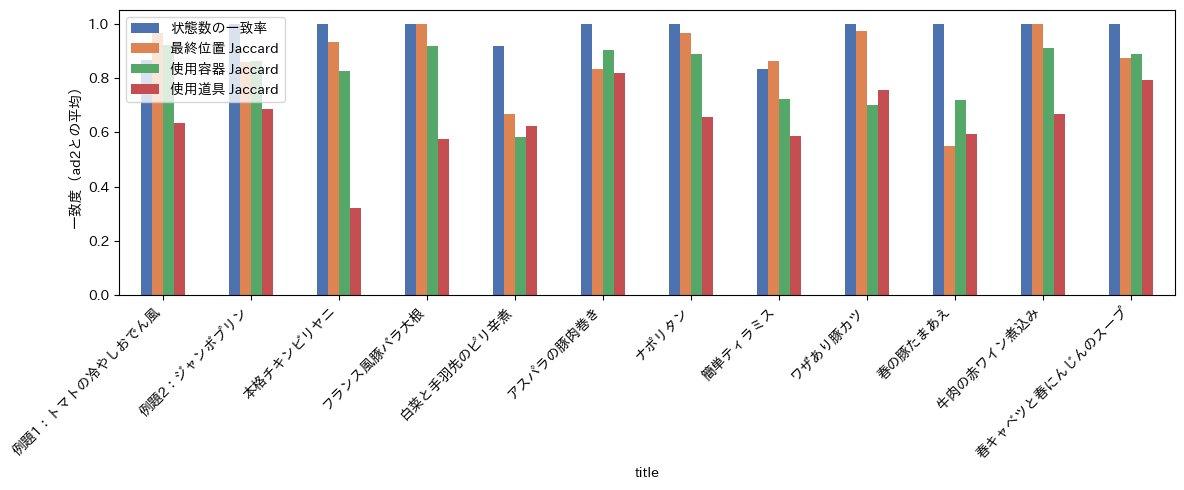

overall n_states match rate: 0.9722222222222222
overall final position jaccard: 0.8810185185185185
overall vessel jaccard: 0.8242989417989417
overall tool jaccard: 0.6407407407407407


In [19]:
# レシピごとの平均一致度（ad2-A, ad2-B, ad2-C の平均）
METRIC_LABELS = {
    "n_steps_match_rate": "状態数の一致率",
    "container_jaccard_mean": "最終位置 Jaccard",
    "vessel_jaccard_mean": "使用容器 Jaccard",
    "tool_jaccard_mean": "使用道具 Jaccard",
}
METRIC_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

ax = per_recipe.set_index("title")[list(METRIC_LABELS)].rename(columns=METRIC_LABELS).plot.bar(
    figsize=(12, 5), color=METRIC_COLORS
)
ax.set_ylabel("一致度（ad2との平均）")
ax.set_ylim(0, 1.05)
ax.legend(title=None)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("overall n_states match rate:", pair_df["n_states_match"].mean())
print("overall final position jaccard:", pair_df["container_jaccard"].mean())
print("overall vessel jaccard:", pair_df["vessel_jaccard"].mean())
print("overall tool jaccard:", pair_df["tool_jaccard"].mean())

## ペアごとの内訳（どの2人の組み合わせで一致度が低いか）

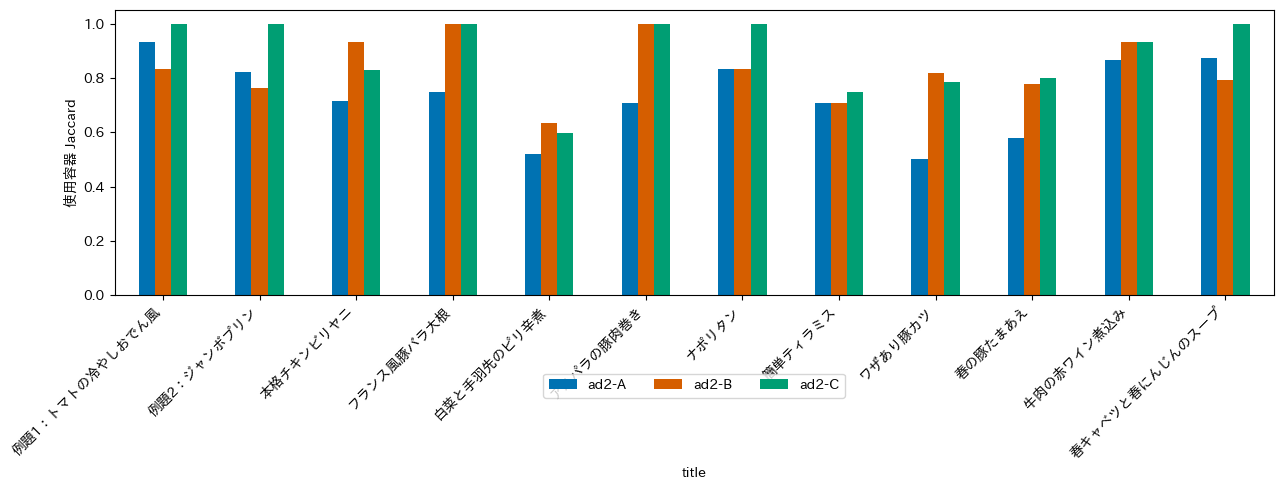

In [20]:
PAIR_ORDER = [f"ad2-{other}" for other in OTHER_ANNOTATORS]
PAIR_PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]
PAIR_COLORS = PAIR_PALETTE[:len(PAIR_ORDER)]

vessel_by_pair = per_recipe_pair.pivot(index="title", columns="pair", values="vessel_jaccard_mean")
vessel_by_pair = vessel_by_pair.loc[titles, PAIR_ORDER]

ax = vessel_by_pair.plot.bar(figsize=(13, 5), color=PAIR_COLORS)
ax.set_ylabel("使用容器 Jaccard")
ax.set_ylim(0, 1.05)
ax.legend(title=None, ncol=len(PAIR_ORDER), loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

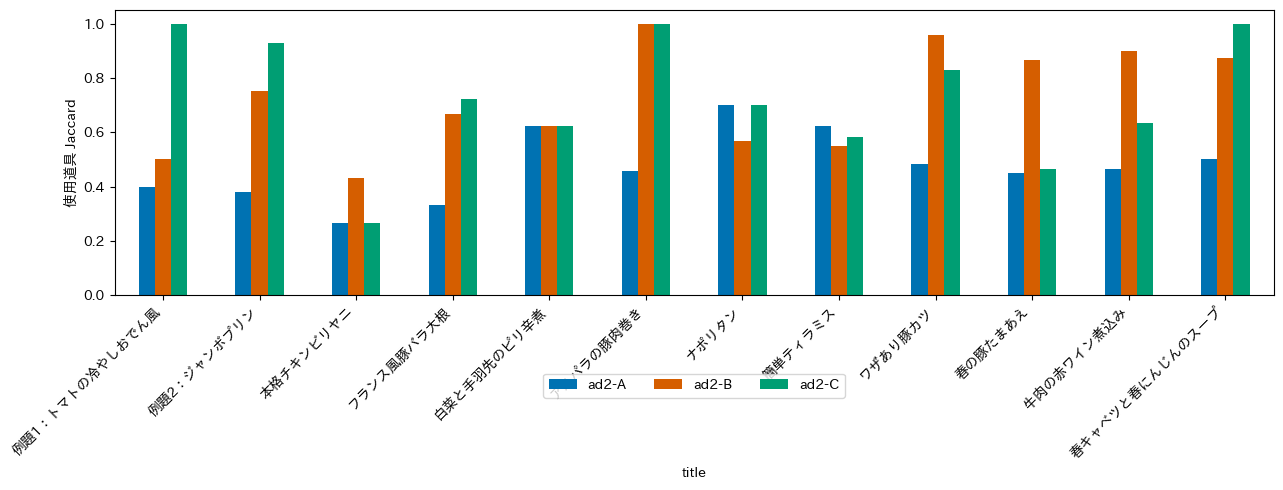

ペアごとの平均一致度:
       n_states_match  container_jaccard  vessel_jaccard  tool_jaccard
pair                                                                  
ad2-A        0.950000           0.834722        0.735635      0.463611
ad2-B        0.983333           0.891667        0.838889      0.725833
ad2-C        0.983333           0.916667        0.898373      0.732778


In [21]:
tool_by_pair = per_recipe_pair.pivot(index="title", columns="pair", values="tool_jaccard_mean")
tool_by_pair = tool_by_pair.loc[titles, PAIR_ORDER]

ax = tool_by_pair.plot.bar(figsize=(13, 5), color=PAIR_COLORS)
ax.set_ylabel("使用道具 Jaccard")
ax.set_ylim(0, 1.05)
ax.legend(title=None, ncol=len(PAIR_ORDER), loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("ペアごとの平均一致度:")
print(pair_df.groupby("pair")[["n_states_match", "container_jaccard", "vessel_jaccard", "tool_jaccard"]].mean())